# UNIVERSIDAD MICHOACANA DE SAN NICOLÁS DE HIDALGO
## FACULTAD DE INGENIERÍA ELÉCTRICA

---

<div align="center">
</div>

---

### **Asignatura:** Inteligencia Artificial  
### **Proyecto:** #7 Rey y Torre contra

**Integrantes del Equipo:**
* Juan Javier Hernández Martinez
* Jesús Alejandro López Gómez


**https://github.com/iosoyyop/baile**
---

Rey y Torre contra Rey consiste en un trabajo en equipo para empujar al rey solitario hacia uno de los bordes del tablero y darle jaque mate. Para lograrlo, la torre actúa como una barrera que limita el movimiento del rey rival fila por fila, mientras tu propio rey avanza para proteger a la torre y bloquear las casillas de escape del enemigo. Una vez que consigues colocar al rival en el borde sin salida con ambos reyes frente a frente, la torre da el jaque definitivo a lo largo de la última línea.

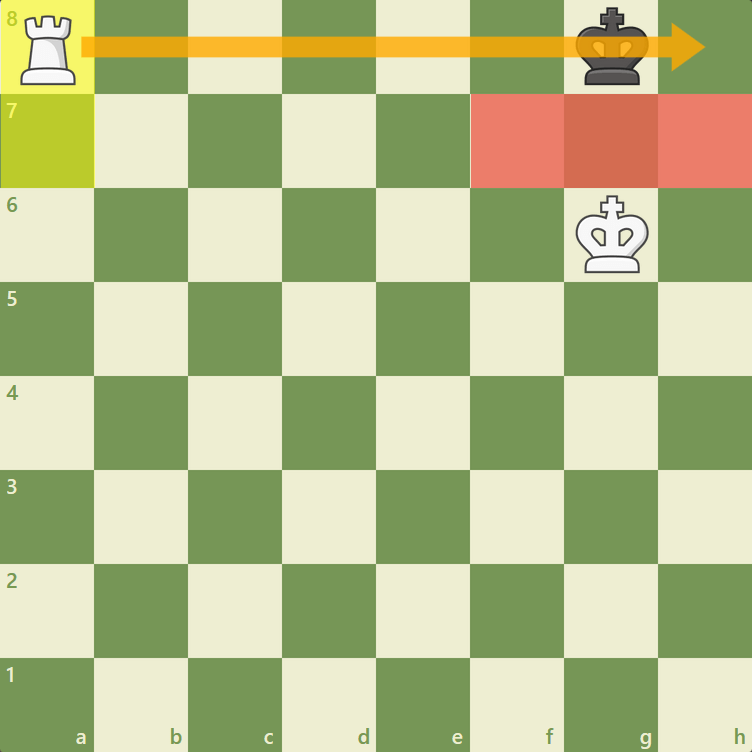

**Estado**

Variables:

● PosWK (vector)
● PosWR (vector)
● PosBK (vector)
● Turno (int || booleano)

El estado inicial es cualquiera posición no ilegal, es decir, no iniciar en jaque
del Black King ni ambos reyes en casillas adyacentes. Esta información de
estado es suficiente porque con la ubicación de las 3 piezas y el turno se
calculan todas las reglas y movimientos sin necesidad de más datos ya que
se busca justamente el jaque mate del Black King y se debe analizar el
movimiento de piezas blancas (White King y White Rook) para alcanzar
dicha condición de meta. Además, la variables son mínimas ya que sin el

turno no se sabe quién mueve, sin la posición de una sola pieza no se
pueden validar choques de reyes ni jaques, y no se requiere guardar
historial de jugadas previa para determinar la legalidad de los turnos
inmediatos.


**Operación sucesor**

Dado un estado S = (PosWK, PosWR, PosBK, Turno)
La operación sucesor genera todas las configuraciones alcanzables según
el jugador en turno:

● Turno Blancas (White):
White King (WK): Se desplaza a cualquiera de sus 8 casillas
adyacentes, siempre que no quede a distancia de 1 casilla del Rey
negro (choque ilegal).
White Rook (WR): Se desplaza horizontal o verticalmente cualquier
número de casillas libres en su fila o columna, sin saltar sobre el WK y
sin estar en peligro de ser comido.

● Turno Negras (Black):
Black King (BK): Se desplaza a cualquiera de sus casillas adyacentes
que no estén atacadas por la Torre blanca ni amenazadas por el Rey
blanco.

Estimación del factor de ramificación promedio (b): - En el turno de las
Blancas, existen en promedio entre 14 y 18 movimientos legales (5 a 8 del
Rey y 8 a 14 de la Torre).
En el turno de las Negras, debido al acorralamiento progresivo, el Rey
dispone de un espacio más reducido, generando entre 2 y 5 movimientos
legales. Por lo tanto, el número de movimientos legales promedio global
por estado se estima en aproximadamente b ≈ 8.5 sucesores por estado.

**Condición de meta**

Lograr jaque mate al Black King cumpliendo las siguientes condiciones:

● Es el turno de las Negras.

● El BK está en Jaque (atacado por WR).

● El número de movimientos legales de BK es cero (MP == 0).

● La Torre no puede ser capturada por el BK (está defendida por WK).

**Heurística candidata**

Calculando a distancia entre reyes, la distancia del Rey negro al centro del
tablero y la restricción de casillas del BK. Esta heurística ayuda a guiar la
búsqueda acelerando la convergencia al mate, obligando al Rey negro a ir
hacia los bordes y evitando perder la Torre o caer en ahogado.

Estimación del tamaño de la búsqueda y tamaño de instancia
1. Tamaño del espacio de estados:



*   Cálculo combinatorio: 64 casillas X 63 X 62 X 2 turnos = 499,968 estados teóricos.
*   Descontando posiciones ilegales (reyes adyacentes, jaques no
resueltos): el espacio real es de ~260,000 estados legales.


2. Tamaño de la instancia a usar:
Uso del tablero completo de 8 X 8 (instancia completa), ya que al ser un espacio reducido (300K estados), es perfectamente computable para exploración
completa con algoritmos como Minimax con poda Alpha-Beta o A*.

In [ ]:
import urllib.request
import importlib.util
import numpy as np
import pandas as pd
import time as t
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

url = "https://raw.githubusercontent.com/iosoyyop/baile/refs/heads/master/src/SimpleSearch.py"

urllib.request.urlretrieve(url, "SimpleSearch.py")

('SimpleSearch.py', <http.client.HTTPMessage at 0x7ef33c9d6e70>)

In [ ]:
import SimpleSearch as sp

In [ ]:
"""
    piezas: Diccionario con el símbolo/pieza como clave y la tupla (fila, col) como valor.
            Ejemplo: {'♔': (0, 4), '♖': (2, 3), '♚': (7, 1)}
    n: Tamaño del tablero (por defecto 8x8).
"""
#Definir el estado (fila_WK, col_WK, fila_WR, col_WR, fila_BK, col_BK, turno)
lejano = sp.node((0, 1, 0, 0, 4, 4, 0), depth=0, parent=None)
promedio = sp.node((0, 4, 2, 3, 7, 1, 0), depth=0, parent=None)
cercano = sp.node((5, 2, 1, 3, 5, 0, 0), depth=0, parent=None)

In [ ]:
def plot_tablero(state):
    n=8 #tamaño tablero

    tablero = [[(i + j) % 2 for j in range(n)] for i in range(n)]
    cmap_chess = ListedColormap(['#777769', '#769656'])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(tablero, cmap=cmap_chess)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    # Mapeamos las coordenadas a sus respectivas piezas con paréntesis ()
    pos = state
    piezas_ajedrez = {
        "♔": (pos[0], pos[1], "white"),  #Rey blanco
        "♖": (pos[2], pos[3], "white"),  #Torre blanca
        "♚": (pos[4], pos[5], "black"),  #Rey negro
    }

    # Dibujar cada pieza usando el nombre correcto de la variable (piezas_ajedrez)
    for simbolo, (fila_pieza, columna_pieza, color_pieza) in piezas_ajedrez.items():
      txt = ax.text(
          columna_pieza,
          fila_pieza,
          simbolo,
          ha="center",
          va="center",
          fontsize=32,
          color=color_pieza,
          fontweight="bold",
      )

    plt.show()

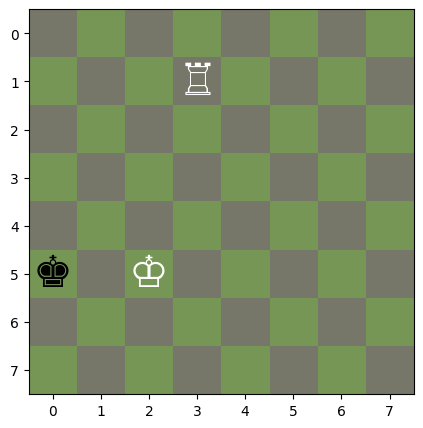

In [ ]:
plot_tablero(cercano.state)

In [ ]:
def estado(nodo):
    st = nodo.state
    ren_K, col_K, ren_R, col_R, ren_k, col_k, turno = st

    # 1. VERIFICAR SI EL REY NEGRO ESTÁ EN JAQUE
    jaque_por_R = False

    if ren_k == ren_R:  # Torre y Rey negro en la misma fila
        if col_k > col_R:
            moverR = 1
        else:
            moverR = -1
        # Comprobar si el Rey blanco está en medio bloqueando el ataque de la Torre
        bloqueado = (ren_K == ren_R) and (col_R < col_K < col_k if moverR == 1 else col_k < col_K < col_R)
        jaque_por_R = not bloqueado

    elif col_k == col_R:  # Torre y Rey negro en la misma columna
        if ren_k > ren_R:
            moverR = 1
        else:
            moverR = -1
        # Comprobar si el Rey blanco está en medio bloqueando la columna
        bloqueado = (col_K == col_R) and (ren_R < ren_K < ren_k if moverR == 1 else ren_k < ren_K < ren_R)
        jaque_por_R = not bloqueado

    jaque = jaque_por_R

    # 2. CONTAR MOVIMIENTOS LEGALES DEL REY NEGRO
    movimientos_legales = 0
    direcciones = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    for dirReng, dirCol in direcciones:
        nuevo_reng_BK_mov, nueva_col_BK_mov = ren_k + dirReng, col_k + dirCol

        # Validar que el movimiento esté dentro de los límites del tablero (8x8)
        if 0 <= nuevo_reng_BK_mov < 8 and 0 <= nueva_col_BK_mov < 8:

            # El Rey negro no puede moverse a casillas adyacentes al Rey blanco
            amenaza_K = max(abs(nuevo_reng_BK_mov - ren_K), abs(nueva_col_BK_mov - col_K)) <= 1

            # Revisar si el movimiento coincide con la fila o columna de la Torre
            en_linea_R = (nuevo_reng_BK_mov == ren_R or nueva_col_BK_mov == col_R)

            # Verificar si el Rey negro va a capturar a la Torre (y si esa Torre no está defendida por su Rey)
            BKcomerR = (nuevo_reng_BK_mov, nueva_col_BK_mov) == (ren_R, col_R) and not amenaza_K

            # Si se mueve a la línea de la Torre sin capturarla, verificar si la casilla está atacada o protegida
            amenaza_R = False
            if en_linea_R and not BKcomerR:
                if nuevo_reng_BK_mov == ren_R:
                    bloqueo = (ren_K == ren_R) and (col_R < col_K < nueva_col_BK_mov if nueva_col_BK_mov > col_R else nueva_col_BK_mov < col_K < col_R)
                    amenaza_R = not bloqueo
                elif nueva_col_BK_mov == col_R:
                    bloqueo = (col_K == col_R) and (ren_R < ren_K < nuevo_reng_BK_mov if nuevo_reng_BK_mov > ren_R else nuevo_reng_BK_mov < ren_K < ren_R)
                    amenaza_R = not bloqueo

            # Si la casilla destino es segura, se contabiliza como movimiento legal
            if not amenaza_K and not amenaza_R:
                movimientos_legales += 1

    return {
        "en_jaque": jaque,
        "movimientos_legales": movimientos_legales
    }


Al declararse como tupla plana es hashable

contiene unicamente la posicion de las piezas y el turno asi que es minima

al agregar turno se da el contexto completo del tablero ya que se sabe donde estan las piezas,quien se debe de mover junto con a donde se puede mover

In [ ]:
def atacado_por_blancas(renglon, columna, ren_K, col_K, ren_R, col_R):
    # Verifica si la casilla (renglon, columna) está amenazada por el Rey o la Torre blanco.
    # 1. Amenaza del Rey Blanco (adyacencia)
    if max(abs(renglon - ren_K), abs(columna - col_K)) <= 1:
        return True

    # 2. Amenaza de la Torre Blanca (mismo renglon/columna sin piezas interrumpiendo)
    if renglon == ren_R:  # Mismo renglon
        if columna > col_R:
          direccion = 1 #Direccion es hacia qué valores se movera la torre respecto de su posicion
        else:
          direccion = -1
        columnInt = range(col_R + direccion, columna, direccion)
        # Si el Rey Blanco NO está bloqueando el paso, la casilla está atacada por la torre
        if not (ren_K == ren_R and col_K in columnInt):
            return True

    elif columna == col_R:  # Misma columna
        if renglon > ren_R:
          direccion = 1
        else:
          direccion = -1
        renInt = range(ren_R + direccion, renglon, direccion)
        if not (col_K == col_R and ren_K in renInt):
            return True

    return False


def sucesor(nodo):
    """
    Función sucesor que genera movimientos válidos según el turno (0 = Blancas, 1 = Negras).
    """
    S = []
    st = nodo.state
    ren_K, col_K, ren_R, col_R, ren_k, col_k, turno = st
    movimientos_rey = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    movimientos_torre = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # TURNO DE LAS BLANCAS (turno == 0)
    if turno == 0:
        # 1. Movimientos del Rey Blanco (WK)
        for mren_WK, mcol_WK in movimientos_rey:
            nuevo_reng_WK, nueva_col_WK = ren_K + mren_WK, col_K + mcol_WK
            if 0 <= nuevo_reng_WK < 8 and 0 <= nueva_col_WK < 8:
                if (nuevo_reng_WK, nueva_col_WK) != (ren_R, col_R) and max(abs(nuevo_reng_WK - ren_k), abs(nueva_col_WK - col_k)) > 1:
                    new_state = (nuevo_reng_WK, nueva_col_WK, ren_R, col_R, ren_k, col_k, 1)
                    S.append(sp.node(
                        new_state,
                        depth=nodo.depth + 1,
                        parent=nodo,
                        op=f"Mover Rey Blanco a ({nuevo_reng_WK}, {nueva_col_WK})"
                    ))

        # 2. Movimientos de la Torre Blanca (WR)
        for mren_R, mcol_R in movimientos_torre:
            for movimiento in range(1, 8):
                nuevo_reng_WR, nueva_col_WR = ren_R + mren_R * movimiento, col_R + mcol_R * movimiento

                if not (0 <= nuevo_reng_WR < 8 and 0 <= nueva_col_WR < 8) or (nuevo_reng_WR, nueva_col_WR) == (ren_K, col_K):
                    break

                # Regular que la torre no se deje comer
                dist_rey_negro = max(abs(nuevo_reng_WR - ren_k), abs(nueva_col_WR - col_k))
                dist_rey_blanco = max(abs(nuevo_reng_WR - ren_K), abs(nueva_col_WR - col_K))

                if dist_rey_negro <= 1 and dist_rey_blanco > 1:
                    continue

                new_state = (ren_K, col_K, nuevo_reng_WR, nueva_col_WR, ren_k, col_k, 1)
                S.append(sp.node(
                    new_state,
                    depth=nodo.depth + 1,
                    parent=nodo,
                    op=f"Mover Torre Blanca a ({nuevo_reng_WR}, {nueva_col_WR})"
                ))

    # TURNO NEGRAS (turno == 1)
    else:
        movimientos_legales = []

        for mren_BK, mcol_BK in movimientos_rey:
            nueva_fila_BK, nueva_col_BK = ren_k + mren_BK, col_k + mcol_BK

            if 0 <= nueva_fila_BK < 8 and 0 <= nueva_col_BK < 8:
                cerca_Rey_Blanco = max(abs(nueva_fila_BK - ren_K), abs(nueva_col_BK - col_K)) <= 1
                es_captura_torre = (nueva_fila_BK, nueva_col_BK) == (ren_R, col_R)

                if es_captura_torre and not cerca_Rey_Blanco:
                    movimientos_legales = [(nueva_fila_BK, nueva_col_BK)]
                    break

                if not cerca_Rey_Blanco and not atacado_por_blancas(nueva_fila_BK, nueva_col_BK, ren_K, col_K, ren_R, col_R):
                    movimientos_legales.append((nueva_fila_BK, nueva_col_BK))

        # POLÍTICA DETERMINISTA DE NEGRAS
        if movimientos_legales:
            mejor_movimiento = max(
                movimientos_legales,
                key=lambda pos: abs(pos[0] - ren_R) + abs(pos[1] - col_R)
            )

            new_state = (ren_K, col_K, ren_R, col_R, mejor_movimiento[0], mejor_movimiento[1], 0)
            S.append(sp.node(
                new_state,
                depth=nodo.depth + 1,
                parent=nodo,
                op=f"Mover Rey Negro a ({mejor_movimiento[0]}, {mejor_movimiento[1]})"
            ))

    return S

Al ser uniforme no se necesita tener un valor asignado para cada movimiento asi que se toma por default el 1, genera hijos de manera correcta con una reglas fijas para las piezas

En el turno del Rey negro se resuelve mediante una política determinista fija: el Rey Negro evalúa sus casillas legales y selecciona únicamente aquella que maximice la distancia Chebyshev respecto a la Torre Blanca."

In [ ]:
def meta(*nodos):
    nodo = nodos[0]

    # Evaluamos el estado del Rey negro en el nodo actual
    evaluacion = estado(nodo)

    # La meta es Jaque Mate: 0 movimientos posibles Y estar en jaque
    jaque_mate = (evaluacion["movimientos_legales"] == 0) and evaluacion["en_jaque"]

    return jaque_mate

Se maneja correctamente el uso de argumentos y el nodo evaluado

Ya que la meta es una propiedad(el jaque mate puede ocurrir de muchas maneras)se ignoro el segundo argumento

In [ ]:
def acorralamiento(*nodos):
    """
    Calcula h(S) = d_Chebyshev(WK, BK) + d_Centro(BK) + P_Seguridad(WR)
    - Minimiza la distancia entre el Rey Blanco y el Rey Negro.
    - Maximiza la distancia del Rey Negro al centro (lo empuja a los bordes).
    """
    nodo = nodos[0]
    st = nodo.state
    ren_K, col_K, ren_R, col_R, ren_k, col_k, turno = st

    # 1. Distancia Chebyshev entre el Rey Blanco y el Rey Negro
    d_reyes = max(abs(ren_K - ren_k), abs(col_K - col_k))

    # 2. Distancia del Rey Negro al centro del tablero (3.5, 3.5)
    d_centro = max(abs(ren_k - 3.5), abs(col_k - 3.5))

    # Penalización por estar cerca del centro: de 0 (en bordes) a 3.5 (en el centro)
    d_centro_penalizacion = 3.5 - d_centro

    # Estimación del costo restante (admisible)
    return d_reyes + d_centro_penalizacion

**¿Qué mide tu heurística y por qué es una estimación razonable del trabajo que falta?**

La heurística mide la suma de la distancia de Chebyshev entre los dos reyes y la penalización por centralización del Rey Negro (0 si está en el borde del tablero, y aumenta linealmente hasta 3.5 si está en el centro) y es razonable pues es matemáticamente imposible dar jaque mate en el centro del tablero, por lo que el Rey Negro debe ser empujado hacia uno de los bordes, además, la Torre no puede dar mate por sí sola ya que requiere que el Rey Blanco esté a una distancia cercana para bloquear las casillas de escape del Rey Negro, por lo tanto, acercar los reyes y arrinconar al rey rival son los dos sub-objetivos fundamentales para ganar

**¿Es admisible?**

No es estrictamente admisible. Podemos demostrar que sobreestima el costo con un contraejemplo en un escenario de "Mate en 1":
Estado **n**:
Rey Negro en a1
Rey Blanco en c2
Torre Blanca en h2.
La Torre Blanca se mueve a h1 y es Jaque Mate. Se requiere exactamente 1 movimiento. Por lo tanto, h^(n) = 1. Como d_centro = max(|0-3.5|, |0-3.5|) = 3.5. Penalización = 3.5 - 3.5 = 0, d_reyes: max(|1-0|, |2-0|) = 2
h(n) = 2 + 0 = 2 y h^(n) = 1, la heurística sobreestima (2 > 1). Al no ser admisible, A* no garantiza encontrar el camino más corto

**¿Cuánto ayuda?**

en casos promedios o lejanos las iteraciones con h(n)=0 se disparan enormemente mientras que en caso cercanos es similar o igual que con heuristica

dificil

* con heuristicas: 6957
* sin heuristicas: 31682

normal
* con heuristicas: 2249
* sin heuristicas: 14801

facil
* con heuristicas: 4
* sin heuristicas: 4

**NUEVA HEURISTICA PROPUESTA**


In [ ]:
"""
def h_distancia_reyes_admisible(*nodos):
  st = nodos[0].state
  ren_K, col_K, ren_R, col_R, ren_k, col_k, turno = st
  d_reyes = max(abs(ren_K - ren_k), abs(col_K - col_k))
  return max(0, d_reyes - 2)

  # Para dar mate, el rey blanco debe estar máximo a 2 de distancia (oposición)
  # Si está más lejos, obligatoriamente tendrá que usar (d_reyes - 2) turnos.
"""
def h_cero(*nodos):
    """
    Esta es la función h(n) = 0 que pide la prueba del reporte.
    Devuelve siempre 0 sin importar el estado.
    """
    return 0

In [ ]:
bfs=sp.TreeSearch(lejano, sucesor, meta, strategy="bfs")
dfs=sp.TreeSearch(lejano, sucesor, meta, strategy="dfs")
bas=sp.TreeSearch(lejano, sucesor, meta, strategy="a*", heuristic=acorralamiento)

In [ ]:
r1=bfs.find()
r2=dfs.find()
r3=bas.find()

In [ ]:
resultados=pd.DataFrame({"Busqueda":["BFS", "DFS", "A*"], "Iteraciones":[bfs.iterations, dfs.iterations, bas.iterations] })

In [ ]:
print(resultados)

  Busqueda  Iteraciones
0      BFS        33158
1      DFS          366
2       A*         6957


In [ ]:
bfs=sp.TreeSearch(promedio, sucesor, meta, strategy="bfs")
dfs=sp.TreeSearch(promedio, sucesor, meta, strategy="dfs")
bas=sp.TreeSearch(promedio, sucesor, meta, strategy="a*", heuristic=acorralamiento)

In [ ]:
r1=bfs.find()
r2=dfs.find()
r3=bas.find()

In [ ]:
resultados=pd.DataFrame({"Busqueda":["BFS", "DFS", "A*"], "Iteraciones":[bfs.iterations, dfs.iterations, bas.iterations] })

In [ ]:
print(resultados)

  Busqueda  Iteraciones
0      BFS        14184
1      DFS         2480
2       A*         2249


In [ ]:
bfs=sp.TreeSearch(cercano, sucesor, meta, strategy="bfs")
dfs=sp.TreeSearch(cercano, sucesor, meta, strategy="dfs")
bas=sp.TreeSearch(cercano, sucesor, meta, strategy="a*", heuristic=acorralamiento)

In [ ]:
r1=bfs.find()
r2=dfs.find()
r3=bas.find()

In [ ]:
resultados=pd.DataFrame({"Busqueda":["BFS", "DFS", "A*"], "Iteraciones":[bfs.iterations, dfs.iterations, bas.iterations] })

In [ ]:
print(resultados)

  Busqueda  Iteraciones
0      BFS           15
1      DFS         2251
2       A*            4


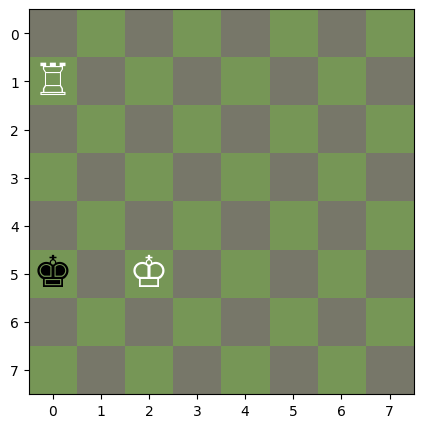

In [ ]:
plot_tablero(r1.state)


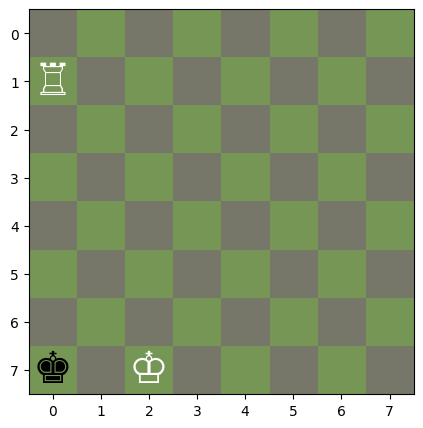

In [ ]:
plot_tablero(r2.state)


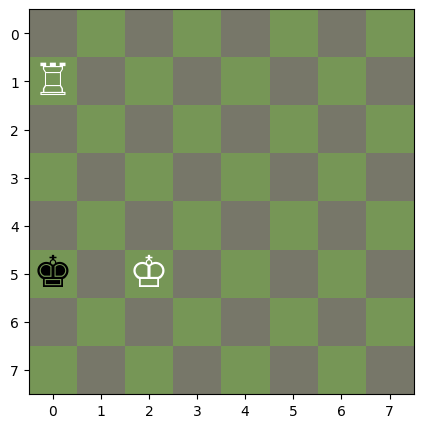

In [ ]:
plot_tablero(r3.state)

In [ ]:
b1=sp.TreeSearch(cercano, sucesor, meta, strategy="dfs")
t0 = t.time()
r = b1.find(max_iter=500000)
tiempoDFS = t.time() - t0
longitudDFS = len(r.getPath()) - 1
costoDFS = r.cost

b2=sp.TreeSearch(cercano, sucesor, meta, strategy="bfs")
t0 = t.time()
r = b2.find(max_iter=500000)
tiempoBFS = t.time() - t0
longitudBFS = len(r.getPath()) - 1
costoBFS = r.cost

b3=sp.TreeSearch(cercano, sucesor, meta, strategy="a*", heuristic=h_cero)
t0 = t.time()
r = b3.find(max_iter=500000)
tiempoA0 = t.time() - t0
longitudA0 = len(r.getPath()) - 1
costoA0 = r.cost

b4=sp.TreeSearch(cercano, sucesor, meta, strategy="a*", heuristic=acorralamiento)
t0 = t.time()
r = b4.find(max_iter=500000)
tiempoAH = t.time() - t0
longitudAH = len(r.getPath()) - 1
costoAH = r.cost

b5=sp.TreeSearch(promedio, sucesor, meta, strategy="dfs")
t0 = t.time()
r = b5.find(max_iter=500000)
tiempoDFSP = t.time() - t0
longitudDFSP = len(r.getPath()) - 1
costoDFSP = r.cost

b6=sp.TreeSearch(promedio, sucesor, meta, strategy="bfs")
t0 = t.time()
r = b6.find(max_iter=500000)
tiempoBFSP = t.time() - t0
longitudBFSP = len(r.getPath()) - 1
costoBFSP = r.cost

b7=sp.TreeSearch(promedio, sucesor, meta, strategy="a*", heuristic=h_cero)
t0 = t.time()
r = b7.find(max_iter=500000)
tiempoA0P = t.time() - t0
longitudA0P = len(r.getPath()) - 1
costoA0P = r.cost

b8=sp.TreeSearch(promedio, sucesor, meta, strategy="a*", heuristic=acorralamiento)
t0 = t.time()
r = b8.find(max_iter=500000)
tiempoAHP = t.time() - t0
longitudAHP = len(r.getPath()) - 1
costoAHP = r.cost

b9=sp.TreeSearch(lejano, sucesor, meta, strategy="dfs")
t0 = t.time()
r = b9.find(max_iter=500000)
tiempoDFSD = t.time() - t0
longitudDFSD = len(r.getPath()) - 1
costoDFSD = r.cost

b10=sp.TreeSearch(lejano, sucesor, meta, strategy="bfs")
t0 = t.time()
r = b10.find(max_iter=500000)
tiempoBFSD = t.time() - t0
longitudBFSD = len(r.getPath()) - 1
costoBFSD = r.cost

b11=sp.TreeSearch(lejano, sucesor, meta, strategy="a*", heuristic=h_cero)
t0 = t.time()
r = b11.find(max_iter=500000)
tiempoA0D = t.time() - t0
longitudA0D = len(r.getPath()) - 1
costoA0D = r.cost

b12=sp.TreeSearch(lejano, sucesor, meta, strategy="a*", heuristic=acorralamiento)
t0 = t.time()
r = b12.find(max_iter=500000)
tiempoAHD = t.time() - t0
longitudAHD = len(r.getPath()) - 1
costoAHD = r.cost

In [ ]:
FheurAnalisis=pd.DataFrame({"Instancia":["Fácil", "Fácil", "Fácil","Fácil"], "Estrategia":["DFS","BFS","A* (h=0)","A* (acorralamiento)"], "Nodos":[b1.iterations, b2.iterations, b3.iterations, b4.iterations],
                           "Tiempo (s)":[tiempoDFS, tiempoBFS, tiempoA0, tiempoAH], "Longitud":[longitudDFS, longitudBFS, longitudA0, longitudAH], "Costo g":[costoDFS, costoBFS, costoA0, costoAH]})
PheurAnalisis=pd.DataFrame({"Instancia":["Promedio", "Promedio", "Promedio","Promedio"], "Estrategia":["DFS","BFS","A* (h=0)","A* (acorralamiento)"], "Nodos":[b5.iterations, b6.iterations, b7.iterations, b8.iterations],
                           "Tiempo (s)":[tiempoDFSP, tiempoBFSP, tiempoA0P, tiempoAHP], "Longitud":[longitudDFSP, longitudBFSP, longitudA0P, longitudAHP], "Costo g":[costoDFSP, costoBFSP, costoA0P, costoAHP]})
DheurAnalisis=pd.DataFrame({"Instancia":["Dificil", "Dificil", "Dificil","Dificil"], "Estrategia":["DFS","BFS","A* (h=0)","A* (acorralamiento)"], "Nodos":[b9.iterations, b10.iterations, b11.iterations, b12.iterations],
                           "Tiempo (s)":[tiempoDFSD, tiempoBFSD, tiempoA0D, tiempoAHD], "Longitud":[longitudDFSD, longitudBFSD, longitudA0D, longitudAHD], "Costo g":[costoDFSD, costoBFSD, costoA0D, costoAHD]})

In [ ]:
print(FheurAnalisis)
print("")
print(PheurAnalisis)
print("")
print(DheurAnalisis)


  Instancia           Estrategia  Nodos  Tiempo (s)  Longitud  Costo g
0     Fácil                  DFS   2251    0.069041      2077     2077
1     Fácil                  BFS     15    0.000326         1        1
2     Fácil             A* (h=0)      4    0.000186         1        1
3     Fácil  A* (acorralamiento)      4    0.000213         1        1

  Instancia           Estrategia  Nodos  Tiempo (s)  Longitud  Costo g
0  Promedio                  DFS   2480    0.073056      2315     2315
1  Promedio                  BFS  14184    0.269003         9        9
2  Promedio             A* (h=0)  14801    0.370866         9        9
3  Promedio  A* (acorralamiento)   2249    0.064072         9        9

  Instancia           Estrategia  Nodos  Tiempo (s)  Longitud  Costo g
0   Dificil                  DFS    366    0.010744       345      345
1   Dificil                  BFS  33158    1.026834        11       11
2   Dificil             A* (h=0)  31682    0.938585        11       11
3   

# CONCLUSION

Gano la estrategia de acorralamiento, esto es porque al tener un objetivo mas especifico a realizar(llevarlo a uno orilla) puede lograr el mate de manera mas eficiente. Mientras que el otro lo empuja desconociendo donde esta o a donde tiene que llevar al rey.

# REFERENCIAS

### Levy, D., & Newborn, M. (1991). How Computers Play Chess. Computer Science Press.

Fundamentos para la evaluación de posiciones en ajedrez por computadora y los finales básicos (K+R vs K).Ayudo a entender por qué el centro es una zona segura para el rey negro y porque se mide la cercania hacia los bordes

### Cantú-Paz, E. (2000). Pragmatic Heuristics for Endgame Play in Chess. IEEE Transactions on Evolutionary Computation.

Justifica el uso de funciones de distancia geométrica (Manhattan / Chebyshev) como métricas de bajo costo computacional para medir el progreso en finales de ajedrez sin requerir tablas de finales.

## Contribuciones

Durante el inicio del proyecto ambos integrantes del equipo hicimos un planteamiento del ejercicio resaltando la base de como funcionaria la logica que se utilizaria.

Durante la fase temprana del desarrollo el compañero **Jesus Alejandro** se dedico a generar la estructura base de como se manejarian los datos de las piezas y sus posiciones al igual que ajustando la impresion del tablero de manera adecuada.
Mientras tanto el compañero **Juan Javier** empezo a contruir la funcion estado y el planteamiento de la funcion meta.

En la intermedia del desarrollo el compañero **Jesus Alejandro** se encargo de diseñar la funcion sucesor y la heuristica que se usaria. Al mismo tiempo el **Juan Javier** se dedico a documentar,mejorar y corregir errores de logica de las funciones ya hechas asi como aislar la logica de los ataques a blancas en una funcion para mejor estructuramiento.

En la fase final del desarrollo ambos integrantes del equipo realizaron los experimentos y pruebas con la heuristica para el analisis de longitudes por coste de las semillas propuestas en los tres escenarios distintos,asi como correcion y mejora de las funciones ya implementadas.

